# Feature Encoding:


 Feature encoding is a crucial step in preparing categorical data for
 machine learning algorithms. Here are some common techniques for feature encoding:
 1. One-Hot Encoding:
    - Converts categorical variables into a series of binary columns.
    - Each category gets its own column, with a 1 indicating presence and 0 absence.
    - Useful for nominal data without intrinsic order.
 2. Label Encoding:
    - Assigns a unique integer to each category.
    - Suitable for ordinal data where the order matters.
 3. Ordinal Encoding:
   - Similar to label encoding but specifically for ordinal categories.
   - Preserves the order of categories.
 4. Binary Encoding:
   - Combines the benefits of one-hot and label encoding
   - Converts categories into binary digits, reducing dimensionality.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
# loding data:
df = sns.load_dataset('tips')

In [ ]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
df['time'].value_counts()


time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [5]:
# pandas get_dummies
pd.get_dummies(df['time'])

,Lunch,Dinner
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True
...,...,...
239,False,True
240,False,True
241,False,True
242,False,True


In [6]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [ ]:
# pandas get_dummies in 'sex' column
pd.get_dummies(df['sex']) 

,Male,Female
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True
...,...,...
239,True,False
240,False,True
241,True,False
242,True,False


In [8]:
# use pandas get_dummies in all columns
pd.get_dummies(df[['sex', 'smoker', 'day', 'time']])

,sex_Male,sex_Female,smoker_Yes,smoker_No,day_Thur,day_Fri,day_Sat,day_Sun,time_Lunch,time_Dinner
0,False,True,False,True,False,False,False,True,False,True
1,True,False,False,True,False,False,False,True,False,True
2,True,False,False,True,False,False,False,True,False,True
3,True,False,False,True,False,False,False,True,False,True
4,False,True,False,True,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...
239,True,False,False,True,False,False,True,False,False,True
240,False,True,True,False,False,False,True,False,False,True
241,True,False,True,False,False,False,True,False,False,True
242,True,False,False,True,False,False,True,False,False,True


In [ ]:
# use the pandas get_dummies in'day' column:


NameError: name 'get_dummies' is not defined

---

# Data Discretization:


In [14]:
from sklearn.preprocessing import KBinsDiscretizer 

In [16]:
df  = sns.load_dataset('titanic')

In [18]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


--

In [20]:
# impute missing values
df['age'].fillna(df['age'].median(), inplace=True)
df['fare'].fillna(df['fare'].median(), inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4028\71241318.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4028\71241318.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [21]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [22]:
# age discritization:
# make the age column into 5 bins:

age_disc = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
age_disc.fit(df[['age']])
df['age_disc'] = age_disc.transform(df[['age']])
df.head() 

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_disc
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,2.0


In [ ]:
# visualize the bin of age column:
sns.displot(df['age_disc'])
# visualize color by age discritization
sns.displot(df, x='age_disc', hue='age')


In [25]:
# define the bin:
bins=[0, 10, 20, 30, 50, 80]
lebls=['kid', 'teen', 'young', 'adult', 'old']
#  use the pd.cut to discretize the 'age' column: 
df['age_group'] = pd.cut(df['age'], bins=bins, labels=lebls)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_disc,age_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1.0,young
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2.0,adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1.0,young
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2.0,adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,2.0,adult


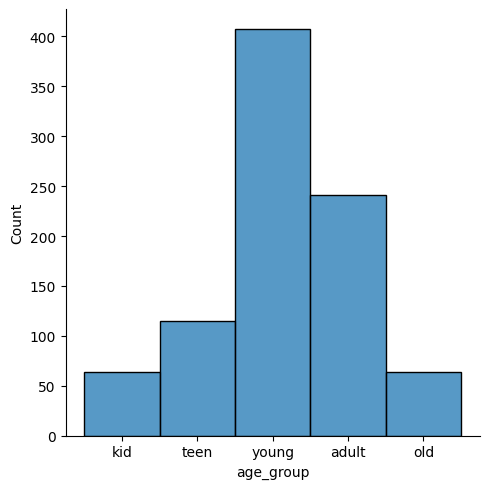

In [ ]:
# visualize the bin of age column:
sns.displot(df['age_group']) 